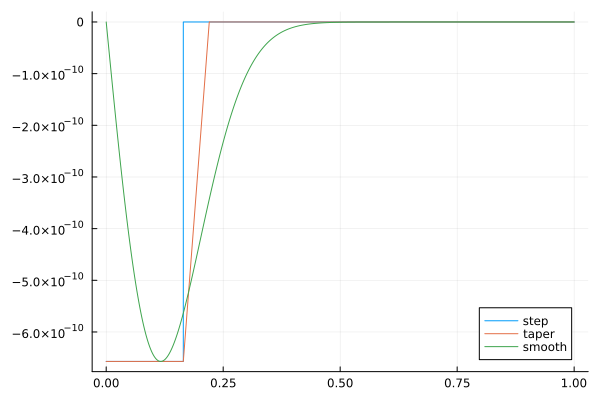

In [7]:
using Plots

r = 0.59
d = 0.025
l = 0.010
r_a = sqrt(2 * r * d / (1 + d/r)^2 )
r_dna = sqrt((d+2*l)*(2*r+2*l))/(1+(2*l+d/2)/r)

# --- DNA 力: 汎用実装 ---
# - mode=:step   : ステップ関数 (力 = -f for r<r_a)
# - mode=:taper  : r_a から r_a+width の間で線形にテーパー
# - mode=:smooth : スムーズな関数（既存の式）

# ステップ関数（配列／スカラー両対応）
dna_force_step(f, r, r_a) = isa(r, AbstractArray) ? ifelse.(r .< r_a, -f, 0.0) : (r < r_a ? -f : 0.0)

# テーパー（幅 width を指定、線形にゼロへ）
function dna_force_taper(f, r, r_a, r2)
    width = r2 - r_a
    if isa(r, AbstractArray)
        vals = zeros(length(r))
        mask1 = r .< r_a
        vals[mask1] .= -f
        if width > 0
            mask2 = (r .>= r_a) .& (r .< r2)
            vals[mask2] .= -f .* ((r2 .- r[mask2]) ./ width)
        end
        return vals
    else
        if r < r_a
            return -f
        elseif width > 0 && r < r2
            return -f * (r2 - r) / width
        else
            return 0.0
        end
    end
end

# スムーズな関数（既存式）
function dna_force_smooth(epsilon, r, r_a)
    return -2 .* epsilon .* r .* exp.(-(r.^2)./(r_a^2)) ./r_a^2 
end

# ラッパー
function dna_force(f, r, r_a; mode=:step, width=0.0)
    if mode == :step
        return dna_force_step(f, r, r_a)
    elseif mode == :taper
        return dna_force_taper(f, r, r_a, width)
    elseif mode == :smooth
        return dna_force_smooth(epsilon, r, r_a)
    else
        error("Unknown mode: $(mode)")
    end
end

# 例: プロット用データ
r = 0:0.00001:1.0
f = 6.57e-10

epsilon = sqrt(exp(1)/2) * r_a * f 

dt = 0.001

forces_step = dna_force(f, r, r_a; mode=:step)
forces_taper = dna_force_taper(f, r, r_a, r_dna)
forces_smooth = dna_force(epsilon, r, r_a; mode=:smooth)

plot(r, forces_step, label="step")
plot!(r, forces_taper, label="taper")
plot!(r, forces_smooth, label="smooth")


In [ ]:
cargo_radius::Float64 = 0.59        # 荷物の半径
d_MT::Float64 = 0.025               # 微小管の直径
r_int::Float64 = 0.1                # 相互作用半径
box_size::Float64 = 16.0            # シミュレーションボックスのサイズ
tau::Float64 = 1.18                 # 時間スケール
dt::Float64 = 0.01                   # タイムステップ
noise_std::Float64 = 0.455         # ノイズの標準偏差
k_cargo::Float64 = 0.001
k_MT::Float64 = 0.004               # 微小管の速度摩擦係数
dna::Float64 = 0.01  
r_out = sqrt(2 * cargo_radius * d_MT/ (1 + d_MT/(2*cargo_radius))^2 ) / cargo_radius

0.16819224534468755